# Lab 2 · Prepare data, draw an SVM boundary, read a decision tree
**Weeks 3–4 | 40-minute core + 18-minute extension | Student notebook**

Can a computer learn to put a new dot in the blue group or the orange group?
Today we will clean two measurements, teach three models, and see how each model separates the dots.
No probability formulas or advanced statistics are needed.

**Before you begin:** Unzip the whole folder. Keep `sensor_groups.csv` beside this notebook.
Open the notebook in Jupyter or VS Code. In Colab, upload the notebook and CSV into the session.
Run cells from top to bottom using **Shift + Enter**. Setup should be completed before the class timer starts.

**How to work:** Cells marked **RUN** are complete. Cells marked **YOUR TURN** contain `...`.
Replace each `...` with the requested code; do not leave it in place. Read the comments before typing.
If stuck for more than a minute, ask your partner or instructor. The instructor has a completed version.

| Core activity | Minutes |
|---|---:|
| 1. Read the data | 4 |
| 2. Split into practice and checking data | 4 |
| 3. Fill missing measurements | 5 |
| 4. Put measurements on similar scales | 5 |
| 5. Train and draw a linear SVM | 6 |
| 6. Try a curved SVM boundary | 4 |
| 7. Train and read a decision tree | 7 |
| 8. Compare and explain | 5 |
| **Core total** | **40** |
| Optional: change C and implement gamma | **18** |

A **feature** is an input measurement. A **label** is the answer we want to predict.
A **model** learns patterns from examples. **Training** means learning; **prediction** means using what it learned.


In [16]:
# RUN: installation is only needed if an import below fails.
# Uncomment the next line if needed, run it, then restart the kernel.
# %pip install numpy pandas matplotlib scikit-learn

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score
from sklearn.inspection import DecisionBoundaryDisplay

plt.rcParams.update({'figure.dpi': 110, 'font.size': 10})


## 1 · Meet the dots — 4 minutes
Each row is a made-up object measured by two sensors. These are **synthetic teaching data**, not real customer or medical records.
`sensor_a` has values in the thousands; `sensor_b` has much smaller values. `group` is 0 or 1.
The group numbers are names, not amounts: group 1 is not “better” than group 0.

**YOUR TURN**
1. Create a variable named `data`. Assign `pd.read_csv("sensor_groups.csv")` to it.
2. Create `missing_counts`. Assign `data.isna().sum()` to it. `isna()` finds blanks; `sum()` counts them in each column.
3. Run the supplied print commands.

Functions: [pd.read_csv](https://pandas.pydata.org/docs/reference/api/pandas.read_csv.html),
[DataFrame.isna](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.isna.html).

**Observe:** Which columns contain missing values? Would a blank reading mean the same thing as a measured zero?


In [17]:
data = pd.read_csv("sensor_groups.csv")
missing_counts = data.isna().sum()
# RUN: these lines display your results.
print(data.head())
print("Rows and columns:", data.shape)
print("Missing entries:\n", missing_counts)
print("Objects in each group:\n", data["group"].value_counts())


      sensor_a  sensor_b  group
0  1696.960320  2.919492      0
1  1892.371377  2.184928      1
2  2882.251420  2.125256      0
3  3386.333125  1.315035      1
4  2280.385166  1.532270      1
Rows and columns: (240, 3)
Missing entries:
 sensor_a    12
sensor_b    12
group        0
dtype: int64
Objects in each group:
 group
0    120
1    120
Name: count, dtype: int64


**Your observation:** Only the sensor columns have missing values, and a blank means "not measured", which is different from a measured zero


## 2 · Separate practice from checking — 4 minutes
Think of the training set as practice questions with answers. The validation set is a short quiz on examples the model did not study.
We call it **validation**, because we will look at it repeatedly to compare models. It is not a final, untouched test set.
A real project needs a separate final test after model choices have been made.

**YOUR TURN**
1. Create `X` using `data[["sensor_a", "sensor_b"]]`. Double brackets select a table of two input columns.
2. Create `y` using `data["group"]`. This holds the correct answers.
3. Complete `train_test_split(X, y, ...)` below. Keep the supplied options.

`test_size=0.25` reserves 25% for checking. `random_state=42` makes the split repeatable.
`stratify=y` keeps similar proportions of the two labels in both parts.

Function: [train_test_split](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html). It returns the four results in the order shown below.

**Observe:** Why must `group` stay out of `X`? How many objects are used for practice and checking?


In [18]:
X = data[["sensor_a", "sensor_b"]]
y = data["group"]
X_train, X_valid, y_train, y_valid = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)
print("Practice rows:", len(X_train))
print("Checking rows:", len(X_valid))


Practice rows: 180
Checking rows: 60


**Your observation:** Group is the answer we want to predict, so including it in X would leak the answer. Practice has 180 rows and checking has 60


## 3 · Fill the blanks — 5 minutes
A missing measurement gives the SVM no usable number. We will replace a blank with the **median** of that sensor's training readings.
The median is the middle number after sorting: for `[2, 3, 100]`, it is 3. One extreme reading moves the mean more than the median.
This replacement is a simple guess; it does not recover the true missing reading.

`fit` means **learn a rule**. `transform` means **apply that rule**.
`fit_transform` does both. Learn replacement values from practice data only.
Learning them from the quiz would allow information from the quiz into preparation: this is **data leakage**.

**YOUR TURN**
1. Create `imputer` by calling `SimpleImputer(strategy="median")`.
2. Assign `imputer.fit_transform(X_train)` to `X_train_clean`.
3. Assign `imputer.transform(X_valid)` to `X_valid_clean`. Do **not** use `fit_transform` here.
The results are number arrays, with the same two columns in the same order.

Function and methods: [SimpleImputer](https://scikit-learn.org/stable/modules/generated/sklearn.impute.SimpleImputer.html).

**Observe:** How many blanks remain? Why do both parts use the same learned medians?


In [19]:
imputer = SimpleImputer(strategy="median")
X_train_clean = imputer.fit_transform(X_train)
X_valid_clean = imputer.transform(X_valid)
# RUN: inspect the learned values and count remaining blanks.
print("Training medians [sensor_a, sensor_b]:", imputer.statistics_)
print("Blanks left in training:", np.isnan(X_train_clean).sum())
print("Blanks left in validation:", np.isnan(X_valid_clean).sum())


Training medians [sensor_a, sensor_b]: [2.48531956e+03 2.18072566e+00]
Blanks left in training: 0
Blanks left in validation: 0


**Your observation:** No blanks remain, and both parts use the training medians so the validation data is prepared by the same rule without leaking information


## 4 · Make the units comparable — 5 minutes
Imagine measuring one distance in millimetres and another in metres. Large numbers do not automatically mean important information.
SVMs are sensitive to feature scales. We will use `StandardScaler` to put both columns on comparable scales.
It subtracts each training column's average and divides by its typical spread (standard deviation).
No manual calculation is needed. Negative scaled values simply mean “below the training average.”

**YOUR TURN**
1. Create `scaler` using `StandardScaler()`.
2. Assign `scaler.fit_transform(X_train_clean)` to `X_train_scaled`.
3. Assign `scaler.transform(X_valid_clean)` to `X_valid_scaled`.

Function and methods: [StandardScaler](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.StandardScaler.html).

**Observe:** Are the two columns now on more similar numerical scales? Did we change the group labels?


In [20]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_clean)
X_valid_scaled = scaler.transform(X_valid_clean)
print("Before scaling:\n", X_train_clean[:3])
print("After scaling:\n", X_train_scaled[:3].round(2))


Before scaling:
 [[2.33263413e+03 1.96155749e+00]
 [1.77055965e+03 2.75876023e+00]
 [2.69480023e+03 2.94138955e+00]]
After scaling:
 [[-0.19 -0.47]
 [-0.82  1.03]
 [ 0.22  1.38]]


**Your observation:** The columns are now on similar scales, and the labels were not changed because only the inputs were scaled


### RUN · Our reusable drawing tool
The original SVM lab supplies plotting code. We do the same here: **run this cell without editing it**.
Call `draw_model(model, inputs, labels, title)` after fitting a model.

Dots are known training objects; background colours are the model's predicted groups.
A black ring marks an SVM **support vector**: a training example involved in determining its boundary.
For a linear SVM, the solid line is the dividing line and the dashed lines mark its margin levels.
Some dots can be inside the margin or on the wrong side; real groups can overlap.
For a tree there are no support-vector rings or margin lines.

Drawing API: [DecisionBoundaryDisplay.from_estimator](https://scikit-learn.org/stable/modules/generated/sklearn.inspection.DecisionBoundaryDisplay.html#sklearn.inspection.DecisionBoundaryDisplay.from_estimator).
This helper is supplied for visual inspection, not as a programming exercise.


In [21]:
# RUN: define the drawing function once; reuse it in the exercises.
from matplotlib.colors import ListedColormap
GROUP_COLOURS = ListedColormap(["#2979b8", "#ef8b2c"])

def draw_model(model, inputs, labels, title, scaled=True, ax=None):
    if ax is None:
        _, ax = plt.subplots(figsize=(6, 4))
    # Background: the group predicted at each location.
    DecisionBoundaryDisplay.from_estimator(
        model, inputs, response_method="predict", ax=ax,
        cmap=GROUP_COLOURS, alpha=0.20, grid_resolution=130
    )
    if isinstance(model, SVC) and model.kernel == "linear":
        # Solid boundary (0), dashed margin levels (-1 and +1).
        DecisionBoundaryDisplay.from_estimator(
            model, inputs, response_method="decision_function", ax=ax,
            plot_method="contour", levels=[-1, 0, 1], colors="black",
            linestyles=["--", "-", "--"], grid_resolution=130
        )
    for label, colour in [(0, "#2979b8"), (1, "#ef8b2c")]:
        mask = np.asarray(labels) == label
        ax.scatter(inputs[mask, 0], inputs[mask, 1], c=colour,
                   s=20, label=f"Group {label}", edgecolors="white", linewidths=0.3)
    if isinstance(model, SVC):
        sv = model.support_vectors_
        ax.scatter(sv[:, 0], sv[:, 1], s=65, facecolors="none",
                   edgecolors="black", linewidths=0.7, label="Support vector")
    unit = " (scaled)" if scaled else " (original units)"
    ax.set(xlabel="sensor_a" + unit, ylabel="sensor_b" + unit, title=title)
    ax.legend(fontsize=8, loc="best")
    return ax


## 5 · Draw a straight dividing line — 6 minutes
A **linear SVM** looks for a straight boundary with a wide margin, while allowing some violations.
Think of the margin as a buffer around the boundary. Support vectors help determine where that boundary goes.
`C` controls the penalty for margin violations. Leave it at 1 for now; we explore it in the extension.

**YOUR TURN**
1. Create `svm_linear` using `SVC(kernel="linear", C=1)`.
2. Train it by calling `svm_linear.fit(X_train_scaled, y_train)`.
3. Create `linear_predictions` using `svm_linear.predict(X_valid_scaled)`.
4. Create `linear_accuracy` using `accuracy_score(y_valid, linear_predictions)`.

Functions: [SVC, fit and predict](https://scikit-learn.org/stable/modules/generated/sklearn.svm.SVC.html), [accuracy_score](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.accuracy_score.html).
Accuracy is the fraction of correct predictions: 0.80 means 80 out of every 100 on that set.
We use it here because our two groups are equally sized and the two kinds of mistake have the same teaching importance.

**Observe:** Is the boundary straight? Can a straight line separate all of these dots?


Linear SVM validation accuracy: 86.7%


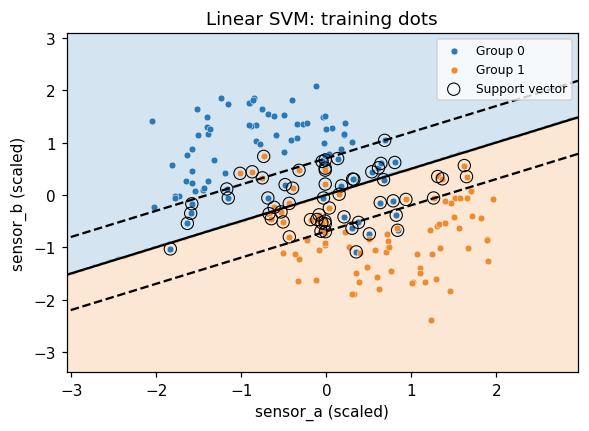

In [22]:
svm_linear = SVC(kernel="linear", C=1)
svm_linear.fit(X_train_scaled, y_train)
linear_predictions = svm_linear.predict(X_valid_scaled)
linear_accuracy = accuracy_score(y_valid, linear_predictions)
print(f"Linear SVM validation accuracy: {linear_accuracy:.1%}")
draw_model(svm_linear, X_train_scaled, y_train, "Linear SVM: training dots")
plt.show()


**Your observation:** The boundary is straight, and one line can't separate all the dots because the groups are curved and overlap


## 6 · Let the boundary bend — 4 minutes
A **kernel** changes the kinds of patterns an SVM can represent.
The `"rbf"` kernel can produce a curved boundary in our picture, without us manually creating extra feature columns.
This is the practical idea behind the kernel trick. Keep `C=1` and `gamma=1` for this first comparison.
`gamma` controls how local the influence of a point is; the optional section explores it visually.

**YOUR TURN**
1. Create `svm_rbf` using `SVC(kernel="rbf", C=1, gamma=1)`.
2. Train it using `.fit(X_train_scaled, y_train)`.
3. Create `rbf_predictions` using `.predict(X_valid_scaled)`.
The accuracy calculation and drawing are supplied.

Function: [SVC](https://scikit-learn.org/stable/modules/generated/sklearn.svm.SVC.html).

**Observe:** How did the shape change? Did validation accuracy increase, decrease, or stay the same?


Linear: 86.7%; RBF: 90.0%


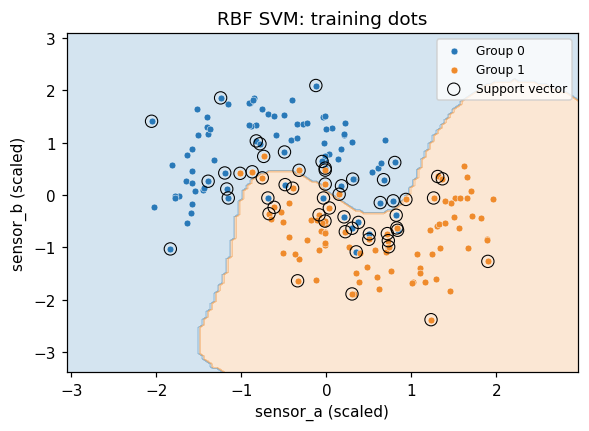

In [23]:
svm_rbf = SVC(kernel="rbf", C=1, gamma=1)
svm_rbf.fit(X_train_scaled, y_train)
rbf_predictions = svm_rbf.predict(X_valid_scaled)
rbf_accuracy = accuracy_score(y_valid, rbf_predictions)
print(f"Linear: {linear_accuracy:.1%}; RBF: {rbf_accuracy:.1%}")
draw_model(svm_rbf, X_train_scaled, y_train, "RBF SVM: training dots")
plt.show()


**Your observation:** The boundary became curved, validation accuracy went up from 86.7% (linear) to 90.0% (RBF)


## 7 · A model that asks yes/no questions — 7 minutes
A decision tree asks questions such as “Is sensor_b at most 2.2?”
It repeats these questions until it reaches a **leaf**, which gives a group prediction.
`max_depth=2` allows at most two questions along a path. The model chooses the questions during training.

A useful split makes its groups less mixed. Compare a box containing 5 blue and 5 orange dots with a box containing 10 blue dots.
The second box is **pure**. Trees can measure this mixing with **Gini impurity**; no formula is required today.

Unlike the SVM, the tree uses one-column thresholds, so it does not need scaling.
We use `X_train_clean` and `X_valid_clean`: blanks filled, original units preserved.

**YOUR TURN**
1. Create `tree` with `DecisionTreeClassifier(max_depth=2, random_state=42)`.
2. Train it using `tree.fit(X_train_clean, y_train)`.
3. Assign `tree.predict(X_valid_clean)` to `tree_predictions`.
4. Run both supplied plots.

Functions: [DecisionTreeClassifier](https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeClassifier.html), [plot_tree](https://scikit-learn.org/stable/modules/generated/sklearn.tree.plot_tree.html).

**Observe:** Read the first question aloud. In the tree diagram, follow left for **True** and right for **False**.
Choose one path and explain which group it predicts. Are the boundary regions curved or rectangular?


Tree validation accuracy: 91.7%


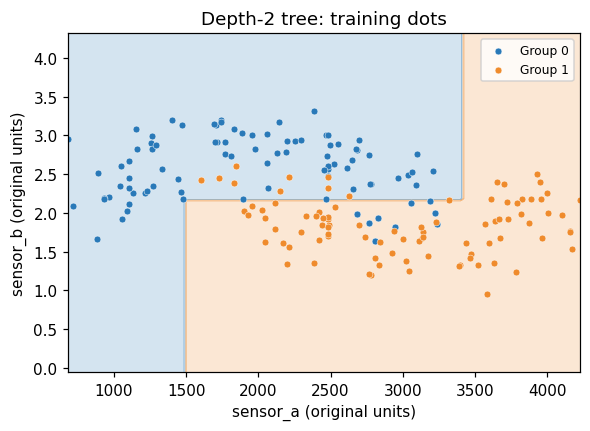

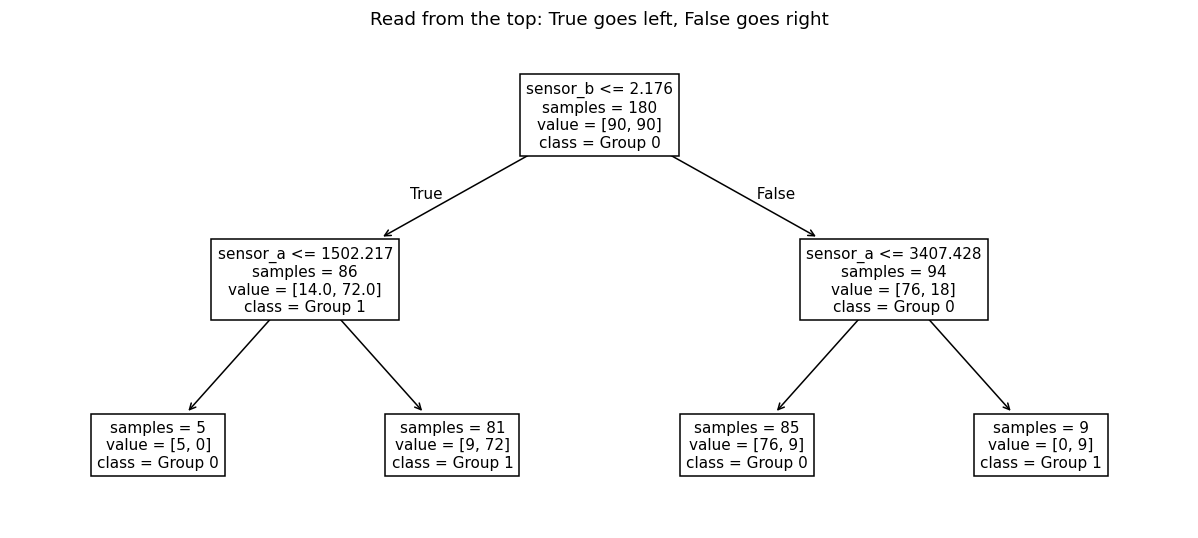

In [24]:
tree = DecisionTreeClassifier(max_depth=2, random_state=42)
tree.fit(X_train_clean, y_train)
tree_predictions = tree.predict(X_valid_clean)
tree_accuracy = accuracy_score(y_valid, tree_predictions)
print(f"Tree validation accuracy: {tree_accuracy:.1%}")
draw_model(tree, X_train_clean, y_train, "Depth-2 tree: training dots", scaled=False)
plt.show()
# RUN: boxes show the question, number of training samples, and predicted group.
plt.figure(figsize=(11, 5))
plot_tree(tree, feature_names=["sensor_a", "sensor_b"],
          class_names=["Group 0", "Group 1"], filled=False,
          impurity=False, label="all", fontsize=10)
plt.title("Read from the top: True goes left, False goes right")
plt.tight_layout()
plt.show()


**Your observation:** The first question is "Is sensor_b <= 2.176?", following True, then False on "sensor_a <= 1502.217" reaches a leaf that predicts Group 1 and the regions are rectangular because each question uses only one column


## 8 · Compare and explain — 5 minutes
**RUN** the completed comparison cell. Training accuracy measures performance on practice examples.
Validation accuracy measures performance on the held-out quiz examples.
A large gap can suggest **overfitting**: learning details of practice examples that do not carry over to new ones.
One small validation set gives only a rough comparison.

**Answer in one sentence each:**
1. Which model scored highest on this validation set? Which two numbers support your answer?
2. Which model is easiest for you to explain as a sequence of questions?
3. What would go wrong if we scaled training inputs but sent unscaled inputs into the same SVM at prediction time?
4. Suppose another dataset has 95 group-0 objects and 5 group-1 objects. A model always predicts 0. Its accuracy is 95%. Does it find any group-1 objects?

**Stop here for the 40-minute session.** You have prepared data, trained two SVMs, read a tree, and checked predictions.


In [25]:
# RUN: each model receives the kind of inputs it was trained on.
comparison = pd.DataFrame({
    "Model": ["Linear SVM", "RBF SVM", "Depth-2 tree"],
    "Training accuracy": [
        svm_linear.score(X_train_scaled, y_train),
        svm_rbf.score(X_train_scaled, y_train),
        tree.score(X_train_clean, y_train)
    ],
    "Validation accuracy": [linear_accuracy, rbf_accuracy, tree_accuracy]
})
print(comparison.round(3).to_string(index=False))


       Model  Training accuracy  Validation accuracy
  Linear SVM              0.878                0.867
     RBF SVM              0.906                0.900
Depth-2 tree              0.900                0.917


**Your answers:**

1. The depth-2 tree scored highest on this validation set, with 91.7% validation accuracy compared with 90.0% for the RBF SVM
2. The decision tree is easiest to explain, because it is just a sequence of yes/no questions about sensor_b and sensor_a
3. The SVM learned its boundary on scaled data, so unscaled inputs at prediction time would sit in the wrong places relative to that boundary and many predictions would be wrong
4. No, because a model that always predicts 0 never finds any group-1 objects, and its 95% accuracy only reflects that the data is imbalanced


# Optional extension · 18 minutes
Complete this only after the core. The experiment code is supplied so you can focus on predictions and observations.
These are **validation experiments**, not a search for a universally best model.

## A · What does C change? — 6 minutes
For the linear SVM, a smaller `C` penalizes margin violations less, allowing more flexibility to keep a wide margin.
A larger `C` penalizes them more strongly. The data still determine the final result; bigger is not automatically better.

**Before running:** Predict which model will have the wider buffer between dashed lines.
**YOUR TURN:** Assign `[0.1, 10]` to `c_values`. Run the supplied loop.
**Observe:** Compare margin width, circled support vectors, and validation accuracy. Does a larger `C` guarantee higher validation accuracy?
Use the SVC documentation linked in section 5 if you want to inspect the parameter.


C=0.1: support vectors=77, validation=86.7%
C=10: support vectors=59, validation=86.7%


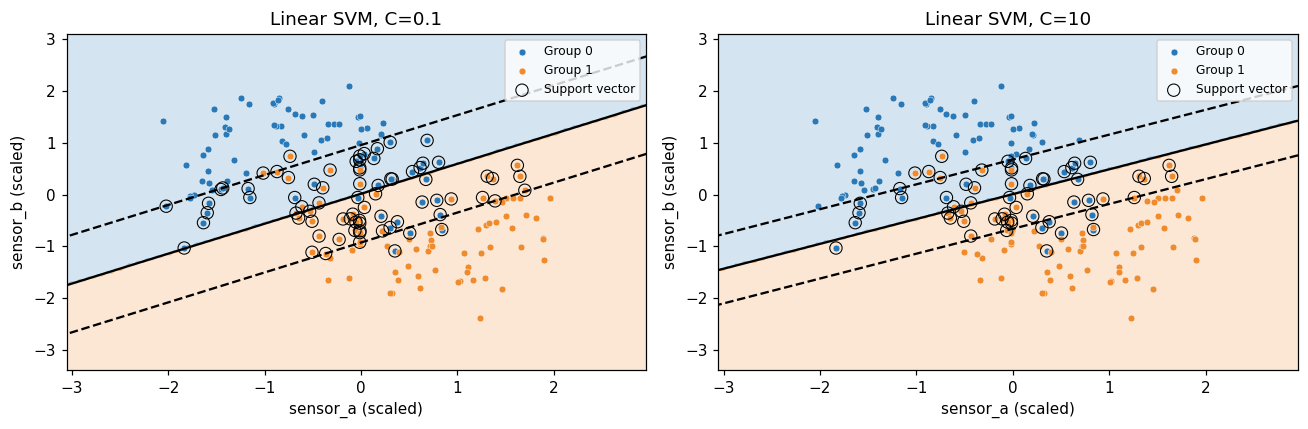

In [26]:
c_values = [0.1, 10]

# RUN: everything below is supplied.
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for c, ax in zip(c_values, axes):
    model = SVC(kernel="linear", C=c)
    model.fit(X_train_scaled, y_train)
    draw_model(model, X_train_scaled, y_train, f"Linear SVM, C={c}", ax=ax)
    print(f"C={c}: support vectors={len(model.support_vectors_)}, "
          f"validation={model.score(X_valid_scaled, y_valid):.1%}")
plt.tight_layout()
plt.show()


**Your observation:** C=0.1 has a wider margin and 77 support vectors against 59 for C=10, and validation was 86.7 on both so a larger C does not guarantee higher validation accuracy.


## Part 12 · Implement the gamma experiment — 12 minutes
This replaces the original 12th code block. Run 12A, then 12B, then 12C after the core exercises.
For an RBF SVM, smaller gamma gives points a broader influence; larger gamma makes it more local.
We keep C=1 so only gamma changes.

**Your task:** Type and run the steps below. Each block includes complete, commented code so you can focus on what each operation does. Before running a line, explain its input and output to your partner.

Functions: [SVC, fit, predict, score](https://scikit-learn.org/stable/modules/generated/sklearn.svm.SVC.html), [accuracy_score](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.accuracy_score.html).
`draw_model` is the supplied helper defined earlier in this notebook.

**Predict first:** Which setting might create smaller, more detailed regions?


### 12A · Create and train two SVMs

In [27]:
# Create svm_low_gamma: use the RBF kernel, C=1, and gamma=0.1.
svm_low_gamma = SVC(kernel="rbf", C=1, gamma=0.1)
# Train it on the scaled practice inputs and their labels.
svm_low_gamma.fit(X_train_scaled, y_train)

# Create svm_high_gamma: change only gamma to 20.
svm_high_gamma = SVC(kernel="rbf", C=1, gamma=20)
# Train it on exactly the same inputs and labels for a fair comparison.
svm_high_gamma.fit(X_train_scaled, y_train)


,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",20
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide <shrinking_svm>`.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide <scores_probabilities>`...deprecated:: 1.9 The `probability` parameter is deprecated and will be removed in 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`.",'deprecated'
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


### 12B · Predict and measure accuracy

In [28]:
# Predict the group of each validation object; store each result separately.
low_predictions = svm_low_gamma.predict(X_valid_scaled)
high_predictions = svm_high_gamma.predict(X_valid_scaled)
# Compare the predictions with the true validation labels.
low_accuracy = accuracy_score(y_valid, low_predictions)
high_accuracy = accuracy_score(y_valid, high_predictions)
# Also measure performance on the practice examples.
low_train_accuracy = svm_low_gamma.score(X_train_scaled, y_train)
high_train_accuracy = svm_high_gamma.score(X_train_scaled, y_train)

print(f"Low gamma: training={low_train_accuracy:.1%}, validation={low_accuracy:.1%}")
print(f"High gamma: training={high_train_accuracy:.1%}, validation={high_accuracy:.1%}")


Low gamma: training=88.9%, validation=85.0%
High gamma: training=96.7%, validation=93.3%


### 12C · Draw and compare

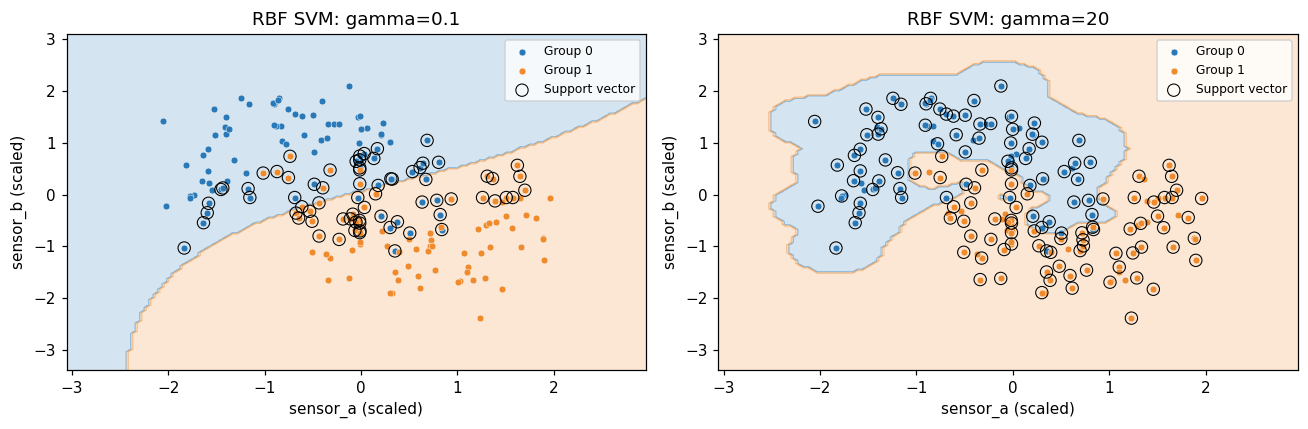

In [29]:
# Create two plotting areas side by side.
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
# Draw each fitted model on the same training dots.
draw_model(svm_low_gamma, X_train_scaled, y_train,
           "RBF SVM: gamma=0.1", ax=axes[0])
draw_model(svm_high_gamma, X_train_scaled, y_train,
           "RBF SVM: gamma=20", ax=axes[1])
plt.tight_layout()
plt.show()


**Observe and explain:**
1. Which boundary has more small regions?
2. Write down both validation scores. Which is higher on this split?
3. Compare training and validation scores. Does fitting more training dots guarantee better predictions on every new dataset?
4. Why did we keep C, the split, and the scaler unchanged?

**Your answers:**

1. gamma=20 has more small regions
2.  Low gamma validation=85.0% // High gamma validation=93.3% - High gamma validation is higher
3. No. High gamma fit the training dots more closely (training 96.7% vs 88.9% for low gamma) and it happened to score higher on validation here (93.3% vs 85.0%), but that is one small split, so a better fit to the practice dots does not guarantee better predictions on every new dataset
4. To change only gamma and make comparison fair

## Keep this small checklist
- Split before learning imputation or scaling settings.
- `fit`: learn. `transform`: apply. `predict`: produce group labels.
- Reuse the training imputer and scaler for new inputs.
- Linear SVM: straight boundary. RBF SVM: can bend. Tree: one-feature questions.
- Judge a model on held-out examples, not only the examples it studied.

**Common fixes:** `NameError` usually means an earlier cell was skipped or a name was misspelled.
An error mentioning `ellipsis` usually means a `...` placeholder remains.
`FileNotFoundError` means the CSV is not in the notebook's working folder.
If you change an earlier cell, rerun the cells that depend on it.

**Next lesson:** Use a scikit-learn Pipeline to package the preprocessing and model together.
If you use cross-validation, refit preprocessing inside each training fold using a pipeline;
do not cross-validate the already scaled arrays from this notebook.

**Scope:** This is a focused selection from Weeks 3–4, not coverage of all reading topics.
Categorical encoding, advanced imputation, feature engineering, resampling, bagging, random forests,
and SVM derivations are reserved for later labs.

**Course sources:** Week 3 office-hours reading, sections 2.2 and 3.2; Week 4 office-hours reading,
sections 1.1–1.3, 1.5, and 3. Adapted to the plot-and-experiment approach of the supplied `IML_PW3.ipynb`.
The synthetic data originate from [make_moons](https://scikit-learn.org/stable/modules/generated/sklearn.datasets.make_moons.html),
with a unit change and missing sensor values added for preprocessing practice. Documentation links checked 2 October 2026.
